In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
FIGURES_DIR = PROJECT_DIR / "figures" / "02_regression_validation"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = SYNTHETIC_DIR / "microct_statistics_dataset.csv"

print("Data path:", DATA_PATH.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

Data path: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\data\synthetic\microct_statistics_dataset.csv
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\figures\02_regression_validation


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 37)


,sample_id,time_index,batch_id,protocol,is_outlier,voltage_kV,current_uA,exposure_ms,n_projections,voxel_size_um,...,cnr_drifted,pore_detectability,detectability_score,segmentation_bias,segmentation_abs_error,estimated_porosity,porosity_error,abs_porosity_error,estimated_mean_pore_diameter_um,quality_score
0,1,0,2,B_optimized,False,139.779264,79.740205,556.875111,1661,67.210426,...,11.970542,4.498315,0.817323,0.002659,0.027658,0.030204,-0.014338,0.014338,286.139470,62.765687
1,2,1,16,B_optimized,False,133.584995,88.224429,509.266539,1568,58.500142,...,11.447199,2.712877,0.428708,-0.013057,0.036648,0.029836,-0.025635,0.025635,159.526529,60.292433
2,3,2,14,B_optimized,False,133.159816,79.573577,669.746240,1346,56.410341,...,13.206688,1.589025,0.196080,-0.017634,0.050556,0.036438,-0.012289,0.012289,78.196105,53.693052
3,4,3,9,B_optimized,False,135.628140,79.754049,671.113602,1778,53.400963,...,13.997532,3.189257,0.547174,-0.019351,0.034133,0.007531,-0.015526,0.015526,140.557286,64.812592
4,5,4,9,B_optimized,False,145.179520,75.327765,803.071348,1107,54.595544,...,9.636927,10.265431,0.999301,0.004142,0.023105,0.048718,0.001730,0.001730,543.656069,64.667183


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nProtocol counts:")
print(df["protocol"].value_counts())

print("\nOutlier counts:")
print(df["is_outlier"].value_counts())

Columns:
['sample_id', 'time_index', 'batch_id', 'protocol', 'is_outlier', 'voltage_kV', 'current_uA', 'exposure_ms', 'n_projections', 'voxel_size_um', 'filter_thickness_mm', 'true_porosity', 'true_mean_pore_diameter_um', 'true_heterogeneity', 'sample_thickness_mm', 'mu_matrix_effective', 'intensity_matrix', 'intensity_pore', 'attenuation_contrast', 'photon_signal', 'photon_signal_norm', 'relative_noise', 'detector_drift', 'relative_noise_drifted', 'snr', 'cnr', 'snr_drifted', 'cnr_drifted', 'pore_detectability', 'detectability_score', 'segmentation_bias', 'segmentation_abs_error', 'estimated_porosity', 'porosity_error', 'abs_porosity_error', 'estimated_mean_pore_diameter_um', 'quality_score']

Missing values:
sample_id        0
time_index       0
batch_id         0
protocol         0
is_outlier       0
voltage_kV       0
current_uA       0
exposure_ms      0
n_projections    0
voxel_size_um    0
dtype: int64

Protocol counts:
protocol
A_standard     509
B_optimized    491
Name: count,

In [4]:
target_column = "abs_porosity_error"

feature_columns = [
    # Acquisition parameters
    "voltage_kV",
    "current_uA",
    "exposure_ms",
    "n_projections",
    "voxel_size_um",
    "filter_thickness_mm",

    # True sample properties
    "true_porosity",
    "true_mean_pore_diameter_um",
    "true_heterogeneity",
    "sample_thickness_mm",

    # Physics-informed image-quality metrics
    "attenuation_contrast",
    "relative_noise_drifted",
    "snr_drifted",
    "cnr_drifted",

    # Detectability
    "pore_detectability",
    "detectability_score",
]

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

Feature matrix: (1000, 16)
Target vector: (1000,)


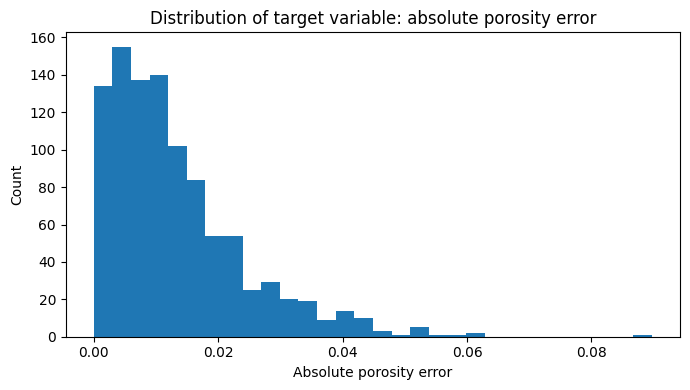

count    1000.000000
mean        0.013261
std         0.011009
min         0.000009
25%         0.005248
50%         0.010635
75%         0.017879
max         0.089741
Name: abs_porosity_error, dtype: float64


In [5]:
plt.figure(figsize=(7, 4))
plt.hist(y, bins=30)
plt.xlabel("Absolute porosity error")
plt.ylabel("Count")
plt.title("Distribution of target variable: absolute porosity error")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_abs_porosity_error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(y.describe())

In [6]:
correlations = (
    df[feature_columns + [target_column]]
    .corr(numeric_only=True)[target_column]
    .sort_values(ascending=False)
)

correlations

abs_porosity_error            1.000000
relative_noise_drifted        0.214298
voxel_size_um                 0.139737
true_porosity                 0.077249
attenuation_contrast          0.044045
sample_thickness_mm           0.041438
true_heterogeneity            0.039412
current_uA                   -0.024772
voltage_kV                   -0.033691
filter_thickness_mm          -0.071042
n_projections                -0.109913
exposure_ms                  -0.113960
snr_drifted                  -0.171207
cnr_drifted                  -0.179789
true_mean_pore_diameter_um   -0.232364
pore_detectability           -0.261836
detectability_score          -0.297754
Name: abs_porosity_error, dtype: float64

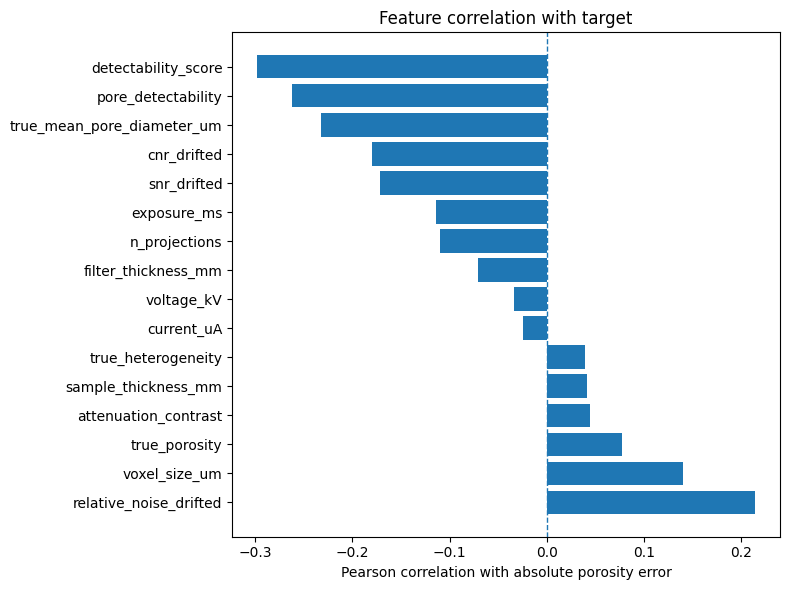

In [7]:
corr_without_target = correlations.drop(target_column)

plt.figure(figsize=(8, 6))
plt.barh(corr_without_target.index, corr_without_target.values)
plt.xlabel("Pearson correlation with absolute porosity error")
plt.title("Feature correlation with target")
plt.axvline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_target_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (750, 16)
Test set: (250, 16)


In [9]:
def evaluate_regression_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Fit a regression model and return evaluation metrics.
    """
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        "model": model_name,

        "train_MAE": mean_absolute_error(y_train, y_pred_train),
        "test_MAE": mean_absolute_error(y_test, y_pred_test),

        "train_RMSE": mean_squared_error(y_train, y_pred_train) ** 0.5,
        "test_RMSE": mean_squared_error(y_test, y_pred_test) ** 0.5,

        "train_R2": r2_score(y_train, y_pred_train),
        "test_R2": r2_score(y_test, y_pred_test),
    }

    return metrics, y_pred_test

In [10]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0005, max_iter=10000))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
}

results = []
predictions = {}

for model_name, model in models.items():
    metrics, y_pred_test = evaluate_regression_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        model_name
    )
    results.append(metrics)
    predictions[model_name] = y_pred_test

results_df = pd.DataFrame(results)
results_df

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Regression,0.007393,0.008663,0.009829,0.011201,0.151156,0.117111
1,Ridge Regression,0.007393,0.008661,0.009829,0.011199,0.151151,0.117440
2,Lasso Regression,0.007483,0.008660,0.009994,0.011359,0.122474,0.091946
3,Random Forest,0.005439,0.008515,0.007299,0.011387,0.531891,0.087496


In [11]:
results_path = RESULTS_DIR / "02_regression_model_comparison.csv"
results_df.to_csv(results_path, index=False)

print(f"Saved model comparison to: {results_path.resolve()}")

Saved model comparison to: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_regression_model_comparison.csv


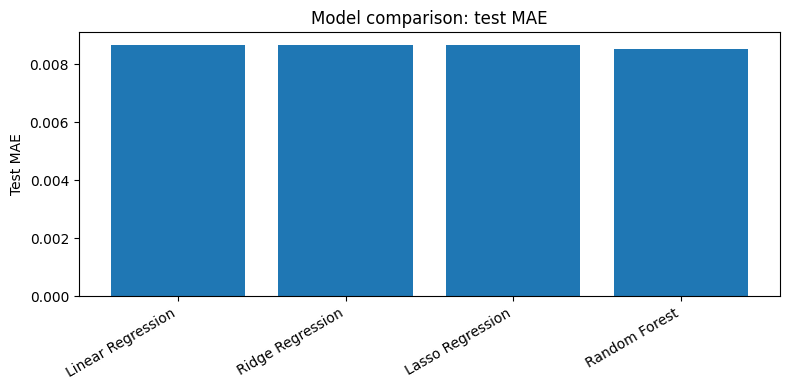

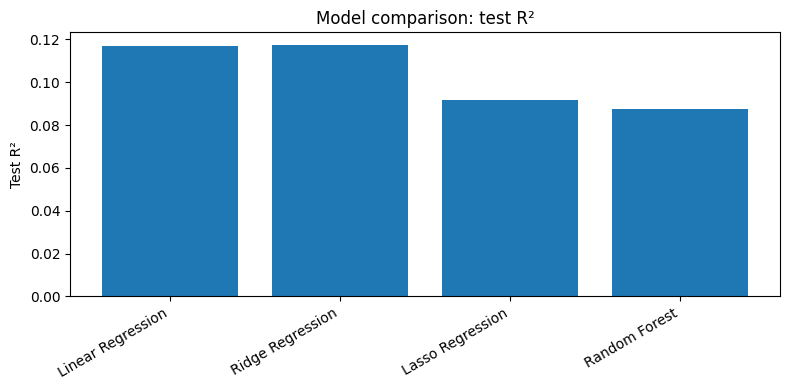

In [12]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_MAE"])
plt.ylabel("Test MAE")
plt.title("Model comparison: test MAE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_test_mae.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["test_R2"])
plt.ylabel("Test R²")
plt.title("Model comparison: test R²")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_test_r2.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "model": model_name,
        "cv_test_MAE_mean": -scores["test_MAE"].mean(),
        "cv_test_MAE_std": scores["test_MAE"].std(),
        "cv_test_RMSE_mean": -scores["test_RMSE"].mean(),
        "cv_test_RMSE_std": scores["test_RMSE"].std(),
        "cv_test_R2_mean": scores["test_R2"].mean(),
        "cv_test_R2_std": scores["test_R2"].std(),
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,model,cv_test_MAE_mean,cv_test_MAE_std,cv_test_RMSE_mean,cv_test_RMSE_std,cv_test_R2_mean,cv_test_R2_std
0,Linear Regression,0.007889,0.000520,0.010349,0.000964,0.095142,0.041752
1,Ridge Regression,0.007885,0.000522,0.010345,0.000967,0.095869,0.040861
2,Lasso Regression,0.007884,0.000598,0.010401,0.001162,0.089948,0.023164
3,Random Forest,0.007913,0.000470,0.010545,0.000914,0.058450,0.060614


In [14]:
cv_results_path = RESULTS_DIR / "02_cross_validation_results.csv"
cv_results_df.to_csv(cv_results_path, index=False)

print(f"Saved cross-validation results to: {cv_results_path.resolve()}")

Saved cross-validation results to: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_cross_validation_results.csv


In [15]:
best_model_name = results_df.sort_values("test_MAE").iloc[0]["model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
results_df.sort_values("test_MAE")

Best model: Random Forest


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
3,Random Forest,0.005439,0.008515,0.007299,0.011387,0.531891,0.087496
2,Lasso Regression,0.007483,0.008660,0.009994,0.011359,0.122474,0.091946
1,Ridge Regression,0.007393,0.008661,0.009829,0.011199,0.151151,0.117440
0,Linear Regression,0.007393,0.008663,0.009829,0.011201,0.151156,0.117111


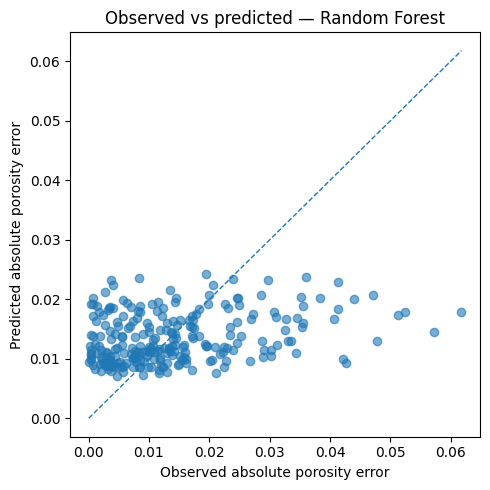

In [16]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, best_predictions, alpha=0.6)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--", linewidth=1)

plt.xlabel("Observed absolute porosity error")
plt.ylabel("Predicted absolute porosity error")
plt.title(f"Observed vs predicted — {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "observed_vs_predicted_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

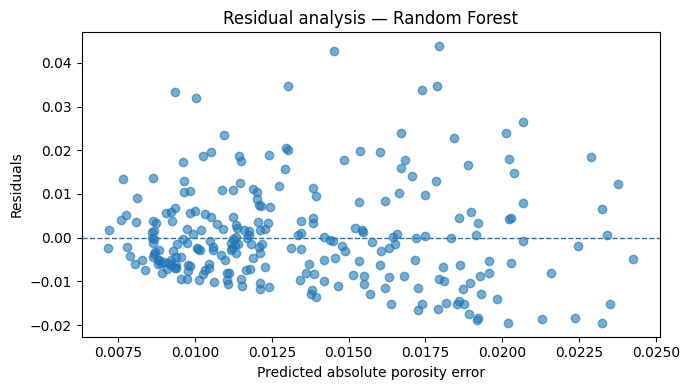

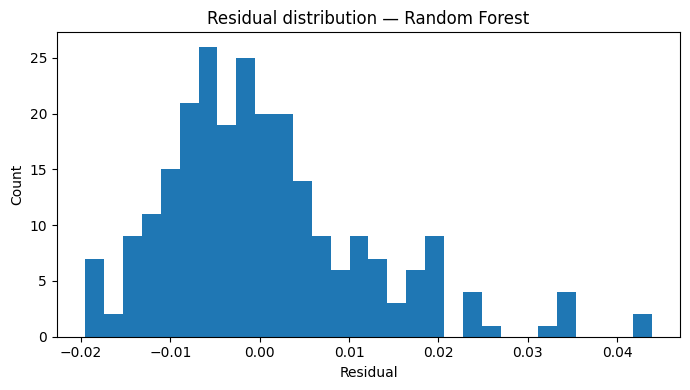

Residual summary:
count    250.000000
mean       0.000521
std        0.011398
min       -0.019508
25%       -0.006944
50%       -0.001431
75%        0.005636
max        0.043843
Name: abs_porosity_error, dtype: float64


In [18]:
residuals = y_test - best_predictions

plt.figure(figsize=(7, 4))
plt.scatter(best_predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Predicted absolute porosity error")
plt.ylabel("Residuals")
plt.title(f"Residual analysis — {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residuals_vs_predictions_best_model.png", dpi=300, bbox_inches="tight")
plt.show()


plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title(f"Residual distribution — {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residual_distribution_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

print("Residual summary:")
print(pd.Series(residuals).describe())

In [19]:
test_results = X_test.copy()
test_results["observed_abs_porosity_error"] = y_test.values
test_results["predicted_abs_porosity_error"] = best_predictions
test_results["residual"] = residuals.values

# Recover protocol from original dataframe using indices
test_results["protocol"] = df.loc[X_test.index, "protocol"].values
test_results["is_outlier"] = df.loc[X_test.index, "is_outlier"].values

protocol_error_summary = (
    test_results
    .groupby("protocol")
    .agg(
        n=("observed_abs_porosity_error", "count"),
        observed_error_mean=("observed_abs_porosity_error", "mean"),
        predicted_error_mean=("predicted_abs_porosity_error", "mean"),
        residual_mean=("residual", "mean"),
        residual_std=("residual", "std")
    )
    .round(5)
)

protocol_error_summary

,n,observed_error_mean,predicted_error_mean,residual_mean,residual_std
protocol,,,,,
A_standard,139,0.01494,0.01481,0.00013,0.01171
B_optimized,111,0.01288,0.01187,0.00101,0.01103


C:\Users\Peter\AppData\Local\Temp\ipykernel_24360\2099424162.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(residual_data, labels=protocols)


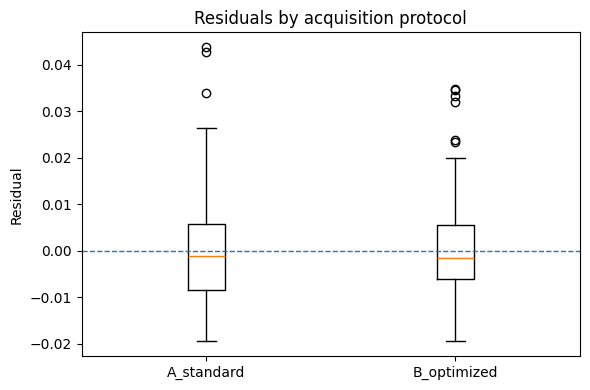

In [20]:
protocols = ["A_standard", "B_optimized"]

residual_data = [
    test_results.loc[test_results["protocol"] == protocol, "residual"]
    for protocol in protocols
]

plt.figure(figsize=(6, 4))
plt.boxplot(residual_data, labels=protocols)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Residual")
plt.title("Residuals by acquisition protocol")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residuals_by_protocol.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
14,pore_detectability,0.121476
15,detectability_score,0.118562
6,true_porosity,0.097938
12,snr_drifted,0.077393
7,true_mean_pore_diameter_um,0.073029
5,filter_thickness_mm,0.068683
0,voltage_kV,0.056877
4,voxel_size_um,0.055818
13,cnr_drifted,0.050730
8,true_heterogeneity,0.049543


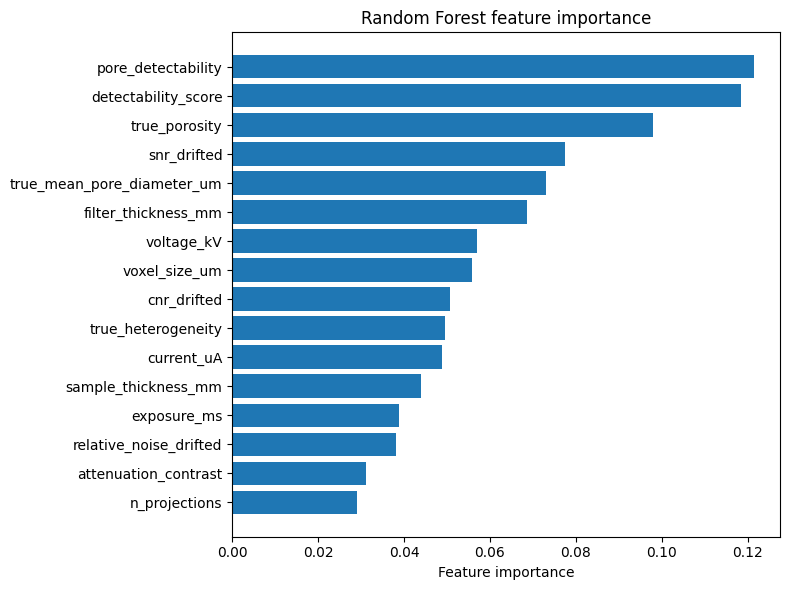

In [22]:
plt.figure(figsize=(8, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Feature importance")
plt.title("Random Forest feature importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
ridge_model = models["Ridge Regression"]
ridge_model.fit(X_train, y_train)

ridge_coefficients = ridge_model.named_steps["model"].coef_

ridge_coef_df = pd.DataFrame({
    "feature": feature_columns,
    "standardized_coefficient": ridge_coefficients
}).sort_values("standardized_coefficient", key=np.abs, ascending=False)

ridge_coef_df

,feature,standardized_coefficient
15,detectability_score,-0.003624
12,snr_drifted,-0.002324
11,relative_noise_drifted,0.002219
3,n_projections,0.001493
6,true_porosity,0.001273
1,current_uA,0.001257
2,exposure_ms,0.000613
8,true_heterogeneity,0.000544
4,voxel_size_um,-0.000416
9,sample_thickness_mm,-0.000403


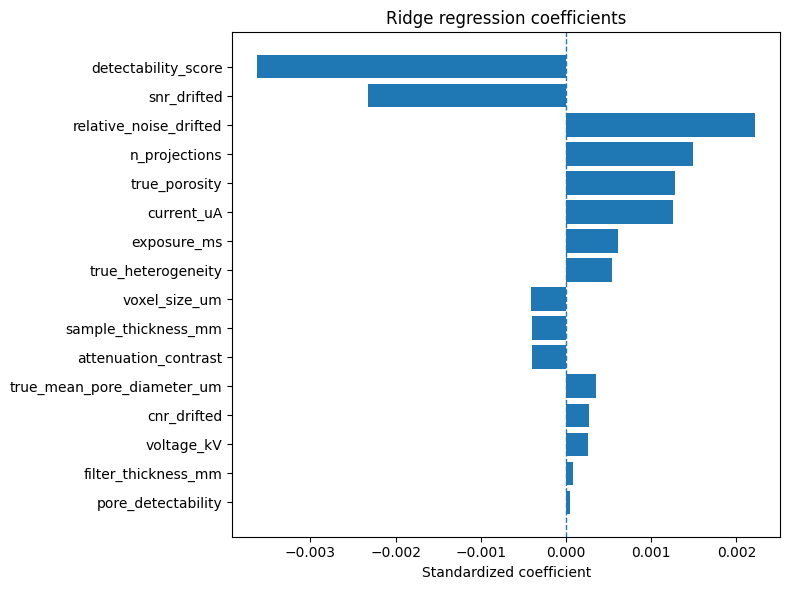

In [24]:
plt.figure(figsize=(8, 6))
plt.barh(
    ridge_coef_df["feature"],
    ridge_coef_df["standardized_coefficient"]
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Standardized coefficient")
plt.title("Ridge regression coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ridge_standardized_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
feature_importance_path = RESULTS_DIR / "02_random_forest_feature_importance.csv"
ridge_coef_path = RESULTS_DIR / "02_ridge_coefficients.csv"
test_predictions_path = RESULTS_DIR / "02_test_predictions_best_model.csv"

feature_importance.to_csv(feature_importance_path, index=False)
ridge_coef_df.to_csv(ridge_coef_path, index=False)
test_results.to_csv(test_predictions_path, index=False)

print("Saved:")
print(feature_importance_path.resolve())
print(ridge_coef_path.resolve())
print(test_predictions_path.resolve())

Saved:
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_random_forest_feature_importance.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_ridge_coefficients.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\02_test_predictions_best_model.csv


In [26]:
print("Regression and model validation notebook completed.")
print()
print("Target variable:")
print(f"- {target_column}")
print()
print("Models evaluated:")
for model_name in models:
    print(f"- {model_name}")
print()
print("Best model based on test MAE:")
print(f"- {best_model_name}")
print()
print("Main validation outputs:")
print("- Train/test metrics")
print("- 5-fold cross-validation")
print("- Observed vs predicted plot")
print("- Residual analysis")
print("- Feature importance")
print("- Ridge standardized coefficients")

Regression and model validation notebook completed.

Target variable:
- abs_porosity_error

Models evaluated:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest

Best model based on test MAE:
- Random Forest

Main validation outputs:
- Train/test metrics
- 5-fold cross-validation
- Observed vs predicted plot
- Residual analysis
- Feature importance
- Ridge standardized coefficients
